# 02 — Experimentos de modelos
**Análisis Predictivo — ITBA 2026**

Pipeline completo: feature engineering · protocolo · baselines · experimentos · holdout temporal.

In [1]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.dummy         import DummyRegressor
from sklearn.linear_model  import LinearRegression, Ridge, Lasso
from sklearn.ensemble      import RandomForestRegressor
from sklearn.impute        import SimpleImputer
from sklearn.pipeline      import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (KFold, cross_validate,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost  as xgb
import lightgbm as lgb

from src.features import build_features

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

In [2]:
df = pd.read_csv('../data/processed/bgg_games_clean.csv')
print(f'Dataset limpio: {len(df):,} juegos  |  columnas: {df.shape[1]}')
df[['game_id','name','year','average','weight']].head(3)

Dataset limpio: 24,251 juegos  |  columnas: 18


,game_id,name,year,average,weight
0,26976,Kingdom Hearts TCG,2006,6.23333,1.500
1,3516,Option,1982,5.66480,2.000
2,392173,Dumb Ways to Die,2023,5.76906,1.125


---
## ⚠️ Protocolo de evaluación — definido ANTES de tocar modelos

| Parámetro | Valor |
|---|---|
| **Métrica principal** | RMSE (escala del target [1–10]) |
| **Métricas secundarias** | MAE, R² |
| **CV** | KFold k=5, shuffle=True, seed=42 |
| **Train** | year ≤ 2023 |
| **Holdout** | year 2024–2026 — **NO TOCAR hasta la evaluación final** |

> El holdout se evalúa **una sola vez**, con el mejor modelo elegido por CV.

In [3]:
# Split temporal
df_train = df[df['year'] <= 2023].reset_index(drop=True)
df_test  = df[df['year'] >= 2024].reset_index(drop=True)

print(f'Train (year <= 2023) : {len(df_train):,} juegos')
print(f'Holdout (2024-2026)  : {len(df_test):,}  juegos')
print(f'  2024: {(df_test["year"]==2024).sum():,}  '
      f'2025: {(df_test["year"]==2025).sum():,}  '
      f'2026: {(df_test["year"]==2026).sum():,}')

# Feature engineering -- fit SOLO en train
X_train, y_train, feat_names, top_mechs, top_cats = build_features(df_train)
X_test,  y_test,  _,          _,         _         = build_features(
    df_test, top_mechs=top_mechs, top_cats=top_cats)

print(f'\nX_train: {X_train.shape}   X_test: {X_test.shape}')
print(f'Features ({len(feat_names)}): {feat_names[:3]} ... {feat_names[-3:]}')

NUM_ONLY = ['weight','year','min_players','max_players',
            'min_playtime','max_playtime','min_age',
            'unlimited_players','n_mechanics','n_categories']
X_num_train = X_train[NUM_ONLY]
X_num_test  = X_test[NUM_ONLY]

Train (year <= 2023) : 22,010 juegos
Holdout (2024-2026)  : 2,241  juegos
  2024: 1,098  2025: 945  2026: 198

X_train: (22010, 80)   X_test: (2241, 80)
Features (80): ['weight', 'year', 'min_players'] ... ['cat_Negotiation', 'cat_Territory_Building', 'cat_City_Building']


In [4]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

SCORING = {
    'rmse': 'neg_root_mean_squared_error',
    'mae':  'neg_mean_absolute_error',
    'r2':   'r2',
}

results_table = []
best_models   = {}

def cv_eval(name, estimator, X=None, y=y_train, store=True):
    # KFold-5, reporta RMSE / MAE / R2
    if X is None:
        X = X_train
    res = cross_validate(estimator, X, y, cv=kf, scoring=SCORING, n_jobs=-1)
    rmse_m = -res['test_rmse'].mean()
    rmse_s =  res['test_rmse'].std()
    mae_m  = -res['test_mae'].mean()
    r2_m   =  res['test_r2'].mean()
    print(f'{name:<44}  RMSE={rmse_m:.4f} +/- {rmse_s:.4f}  MAE={mae_m:.4f}  R2={r2_m:.4f}')
    if store:
        results_table.append({
            'Modelo':    name,
            'RMSE_mean': rmse_m,
            'RMSE_std':  rmse_s,
            'MAE':       mae_m,
            'R2':        r2_m,
        })
    return rmse_m, rmse_s

---
## 1. Baselines

Dos referencias mínimas. Cualquier modelo real debe superar la Baseline 2.

In [5]:
print('=' * 78)
print('BASELINES')
print('=' * 78)

dummy = Pipeline([('mdl', DummyRegressor(strategy='mean'))])
cv_eval('Baseline 1 -- media constante (train)', dummy)

BASELINES


Baseline 1 -- media constante (train)         RMSE=0.8559 +/- 0.0064  MAE=0.6685  R2=-0.0002


(np.float64(0.8558720508092627), np.float64(0.006370641850347781))

In [6]:
lr_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler()),
    ('mdl', LinearRegression()),
])
cv_eval('Baseline 2 -- LinearRegression (solo numericas)', lr_pipe, X=X_num_train)

print()
print('>> RMSE a superar con features completas: resultado Baseline 2 <<')

Baseline 2 -- LinearRegression (solo numericas)  RMSE=0.6469 +/- 0.0058  MAE=0.4886  R2=0.4284

>> RMSE a superar con features completas: resultado Baseline 2 <<


---
## 2. Experimentos

Todos usan las **features completas** (numéricas + top-40 mecánicas + top-30 categorías).
NaN numéricos: imputados por mediana en pipeline para modelos lineales/RF; nativos en XGBoost/LightGBM.

In [7]:
print('=' * 78)
print('RIDGE -- GridSearch  |  alpha in {0.01, 0.1, 1, 10, 100, 1000, 10000}')
print('=' * 78)

ridge_base = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler()),
    ('mdl', Ridge()),
])
ridge_gs = GridSearchCV(
    ridge_base,
    param_grid={'mdl__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]},
    cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1,
)
ridge_gs.fit(X_train, y_train)
best_alpha_r = ridge_gs.best_params_['mdl__alpha']
print(f'Mejor alpha: {best_alpha_r}')

ridge_best = ridge_gs.best_estimator_
cv_eval(f'Ridge  (alpha={best_alpha_r})', ridge_best)
best_models['Ridge'] = (ridge_best, X_train)

RIDGE -- GridSearch  |  alpha in {0.01, 0.1, 1, 10, 100, 1000, 10000}


Mejor alpha: 100.0


Ridge  (alpha=100.0)                          RMSE=0.6224 +/- 0.0071  MAE=0.4685  R2=0.4710


In [8]:
print('=' * 78)
print('LASSO -- GridSearch  |  alpha in {1e-4, 1e-3, 0.01, 0.1, 1, 10}')
print('=' * 78)

lasso_base = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler()),
    ('mdl', Lasso(max_iter=5000)),
])
lasso_gs = GridSearchCV(
    lasso_base,
    param_grid={'mdl__alpha': [1e-4, 1e-3, 0.01, 0.1, 1.0, 10.0]},
    cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1,
)
lasso_gs.fit(X_train, y_train)
best_alpha_l = lasso_gs.best_params_['mdl__alpha']
print(f'Mejor alpha: {best_alpha_l}')

lasso_best = lasso_gs.best_estimator_
cv_eval(f'Lasso  (alpha={best_alpha_l})', lasso_best)
best_models['Lasso'] = (lasso_best, X_train)

LASSO -- GridSearch  |  alpha in {1e-4, 1e-3, 0.01, 0.1, 1, 10}


Mejor alpha: 0.001


Lasso  (alpha=0.001)                          RMSE=0.6222 +/- 0.0071  MAE=0.4683  R2=0.4711


In [9]:
print('=' * 78)
print('RANDOM FOREST -- RandomizedSearch (n_iter=10)')
print('Espacio: n_est=[100,200], depth=[10,20,None],')
print('         min_leaf=[2,5,10], max_features=[sqrt,0.4]')
print('=' * 78)

rf_base = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('mdl', RandomForestRegressor(random_state=SEED, n_jobs=-1)),
])
rf_param = {
    'mdl__n_estimators':    [100, 200],
    'mdl__max_depth':       [10, 20, None],
    'mdl__min_samples_leaf':[2, 5, 10],
    'mdl__max_features':    ['sqrt', 0.4],
}
rf_rs = RandomizedSearchCV(
    rf_base, rf_param, n_iter=10, cv=kf,
    scoring='neg_root_mean_squared_error',
    random_state=SEED, n_jobs=1, verbose=0,
)
rf_rs.fit(X_train, y_train)
bp = rf_rs.best_params_
print(f'Mejores params: {bp}')

rf_best = rf_rs.best_estimator_
cv_eval(f'RandomForest  (depth={bp["mdl__max_depth"]}, leaf={bp["mdl__min_samples_leaf"]})', rf_best)
best_models['RandomForest'] = (rf_best, X_train)

RANDOM FOREST -- RandomizedSearch (n_iter=10)
Espacio: n_est=[100,200], depth=[10,20,None],
         min_leaf=[2,5,10], max_features=[sqrt,0.4]


Mejores params: {'mdl__n_estimators': 200, 'mdl__min_samples_leaf': 2, 'mdl__max_features': 0.4, 'mdl__max_depth': None}


RandomForest  (depth=None, leaf=2)            RMSE=0.5775 +/- 0.0051  MAE=0.4311  R2=0.5445


In [10]:
print('=' * 78)
print('XGBOOST -- RandomizedSearch (n_iter=15, NaN nativo)')
print('Espacio: lr=[0.05,0.1,0.3], depth=[4,6,8], n_est=[200,300,500],')
print('         subsample=[0.8,1.0], colsample=[0.7,0.9]')
print('=' * 78)

xgb_param = {
    'learning_rate':    [0.05, 0.1, 0.3],
    'max_depth':        [4, 6, 8],
    'n_estimators':     [200, 300, 500],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.7, 0.9],
    'min_child_weight': [1, 3, 5],
}
xgb_model = xgb.XGBRegressor(
    random_state=SEED, n_jobs=-1, tree_method='hist', verbosity=0,
)
xgb_rs = RandomizedSearchCV(
    xgb_model, xgb_param, n_iter=15, cv=kf,
    scoring='neg_root_mean_squared_error',
    random_state=SEED, n_jobs=1, verbose=0,
)
xgb_rs.fit(X_train, y_train)
bp = xgb_rs.best_params_
print(f'Mejores params: {bp}')

xgb_best = xgb_rs.best_estimator_
cv_eval(f'XGBoost  (lr={bp["learning_rate"]}, depth={bp["max_depth"]}, n={bp["n_estimators"]})', xgb_best)
best_models['XGBoost'] = (xgb_best, X_train)

XGBOOST -- RandomizedSearch (n_iter=15, NaN nativo)
Espacio: lr=[0.05,0.1,0.3], depth=[4,6,8], n_est=[200,300,500],
         subsample=[0.8,1.0], colsample=[0.7,0.9]


Mejores params: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


XGBoost  (lr=0.05, depth=6, n=500)            RMSE=0.5698 +/- 0.0054  MAE=0.4268  R2=0.5565


In [11]:
print('=' * 78)
print('LIGHTGBM -- RandomizedSearch (n_iter=20, NaN nativo)')
print('Espacio: lr=[0.03,0.05,0.1], leaves=[31,63,127], n_est=[300,500,800],')
print('         min_child=[10,20,50], subsample=[0.8,0.9,1.0],')
print('         colsample=[0.7,0.8,0.9], reg_a=[0,0.1], reg_l=[0,0.1,1]')
print('=' * 78)

lgb_param = {
    'learning_rate':     [0.03, 0.05, 0.1],
    'num_leaves':        [31, 63, 127],
    'n_estimators':      [300, 500, 800],
    'min_child_samples': [10, 20, 50],
    'subsample':         [0.8, 0.9, 1.0],
    'colsample_bytree':  [0.7, 0.8, 0.9],
    'reg_alpha':         [0.0, 0.1],
    'reg_lambda':        [0.0, 0.1, 1.0],
}
lgb_model = lgb.LGBMRegressor(random_state=SEED, n_jobs=-1, verbose=-1)
lgb_rs = RandomizedSearchCV(
    lgb_model, lgb_param, n_iter=20, cv=kf,
    scoring='neg_root_mean_squared_error',
    random_state=SEED, n_jobs=1, verbose=0,
)
lgb_rs.fit(X_train, y_train)
bp = lgb_rs.best_params_
print(f'Mejores params: {bp}')

lgb_best = lgb_rs.best_estimator_
cv_eval(f'LightGBM  (lr={bp["learning_rate"]}, leaves={bp["num_leaves"]}, n={bp["n_estimators"]})', lgb_best)
best_models['LightGBM'] = (lgb_best, X_train)

LIGHTGBM -- RandomizedSearch (n_iter=20, NaN nativo)
Espacio: lr=[0.03,0.05,0.1], leaves=[31,63,127], n_est=[300,500,800],
         min_child=[10,20,50], subsample=[0.8,0.9,1.0],
         colsample=[0.7,0.8,0.9], reg_a=[0,0.1], reg_l=[0,0.1,1]


Mejores params: {'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alpha': 0.0, 'num_leaves': 63, 'n_estimators': 800, 'min_child_samples': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


LightGBM  (lr=0.03, leaves=63, n=800)         RMSE=0.5698 +/- 0.0054  MAE=0.4260  R2=0.5565


In [12]:
print()
print('=' * 78)
print('TABLA COMPARATIVA -- CV (k=5, seed=42)')
print('=' * 78)

res_df = (pd.DataFrame(results_table)
          .sort_values('RMSE_mean')
          .reset_index(drop=True))
res_df.index = res_df.index + 1

display_rows = []
for _, row in res_df.iterrows():
    display_rows.append({
        'Modelo':  row['Modelo'],
        'RMSE CV': f"{row['RMSE_mean']:.4f} +/- {row['RMSE_std']:.4f}",
        'MAE':     f"{row['MAE']:.4f}",
        'R2':      f"{row['R2']:.4f}",
    })
print(pd.DataFrame(display_rows).to_string(index=True))

best_name = res_df.iloc[0]['Modelo']
best_rmse = res_df.iloc[0]['RMSE_mean']
print(f'\nMejor modelo por CV: {best_name}  (RMSE={best_rmse:.4f})')


TABLA COMPARATIVA -- CV (k=5, seed=42)
                                            Modelo            RMSE CV     MAE       R2
0            LightGBM  (lr=0.03, leaves=63, n=800)  0.5698 +/- 0.0054  0.4260   0.5565
1               XGBoost  (lr=0.05, depth=6, n=500)  0.5698 +/- 0.0054  0.4268   0.5565
2               RandomForest  (depth=None, leaf=2)  0.5775 +/- 0.0051  0.4311   0.5445
3                             Lasso  (alpha=0.001)  0.6222 +/- 0.0071  0.4683   0.4711
4                             Ridge  (alpha=100.0)  0.6224 +/- 0.0071  0.4685   0.4710
5  Baseline 2 -- LinearRegression (solo numericas)  0.6469 +/- 0.0058  0.4886   0.4284
6            Baseline 1 -- media constante (train)  0.8559 +/- 0.0064  0.6685  -0.0002

Mejor modelo por CV: LightGBM  (lr=0.03, leaves=63, n=800)  (RMSE=0.5698)


---
## ⚠️ Evaluación final — holdout temporal 2024–2026

Ejecutada **una sola vez** con el mejor modelo por CV. Mide la degradación real por shift temporal.

In [13]:
# Buscar la clave corta en best_models que corresponde al mejor modelo
SHORT_KEYS = ['LightGBM', 'XGBoost', 'RandomForest', 'Lasso', 'Ridge']
best_key   = next((k for k in SHORT_KEYS if k.lower() in best_name.lower()), SHORT_KEYS[0])
best_est, X_used = best_models[best_key]
best_est.fit(X_used, y_train)

y_pred_holdout = best_est.predict(X_test)
rmse_holdout = np.sqrt(mean_squared_error(y_test, y_pred_holdout))
mae_holdout  = mean_absolute_error(y_test, y_pred_holdout)
r2_holdout   = r2_score(y_test, y_pred_holdout)

print('=' * 78)
print(f'HOLDOUT TEMPORAL (2024-2026)  -- n={len(y_test):,} juegos')
print('=' * 78)
print(f'  RMSE holdout  : {rmse_holdout:.4f}')
print(f'  MAE  holdout  : {mae_holdout:.4f}')
print(f'  R2   holdout  : {r2_holdout:.4f}')
print()
degradacion = (rmse_holdout - best_rmse) / best_rmse * 100
print(f'  RMSE CV (best): {best_rmse:.4f}')
print(f'  Degradacion   : {degradacion:+.1f}%  (holdout vs. CV)')
if abs(degradacion) < 5:
    print('  >> Degradacion < 5% -- modelo estable ante shift temporal.')
elif abs(degradacion) < 15:
    print('  >> Degradacion moderada -- el modelo generaliza razonablemente.')
else:
    print('  >> Degradacion alta -- revisar si "year" captura el sesgo de recencia.')

HOLDOUT TEMPORAL (2024-2026)  -- n=2,241 juegos
  RMSE holdout  : 0.6373
  MAE  holdout  : 0.4654
  R2   holdout  : 0.2999

  RMSE CV (best): 0.5698
  Degradacion   : +11.8%  (holdout vs. CV)
  >> Degradacion moderada -- el modelo generaliza razonablemente.


TOP 15 FEATURE IMPORTANCES -- LightGBM  (lr=0.03, leaves=63, n=800)


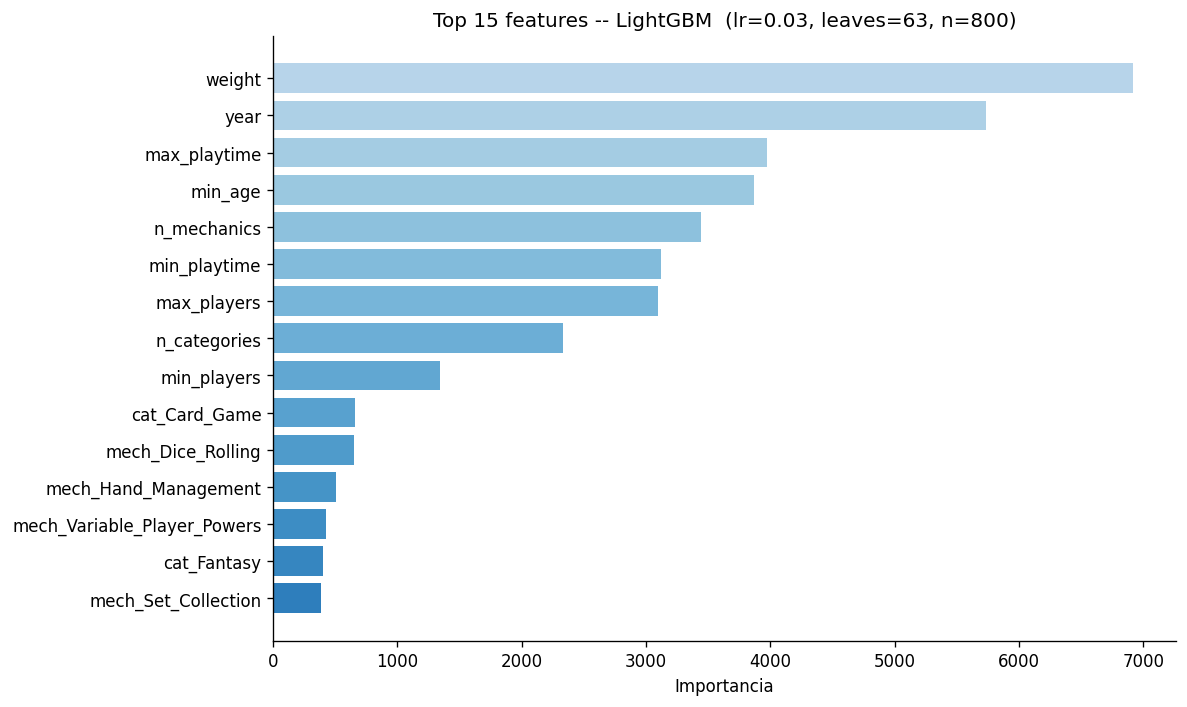


Top 15:
   1. weight                               6916.0000
   2. year                                 5737.0000
   3. max_playtime                         3969.0000
   4. min_age                              3869.0000
   5. n_mechanics                          3440.0000
   6. min_playtime                         3121.0000
   7. max_players                          3093.0000
   8. n_categories                         2329.0000
   9. min_players                          1338.0000
  10. cat_Card_Game                        656.0000
  11. mech_Dice_Rolling                    650.0000
  12. mech_Hand_Management                 508.0000
  13. mech_Variable_Player_Powers          426.0000
  14. cat_Fantasy                          402.0000
  15. mech_Set_Collection                  388.0000


In [14]:
print('=' * 78)
print(f'TOP 15 FEATURE IMPORTANCES -- {best_name}')
print('=' * 78)

mdl = best_est
if hasattr(mdl, 'named_steps'):
    mdl = mdl.named_steps.get('mdl', mdl)

if hasattr(mdl, 'feature_importances_'):
    importances = mdl.feature_importances_
elif hasattr(mdl, 'coef_'):
    importances = np.abs(mdl.coef_)
else:
    importances = None

if importances is not None:
    imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)
    top15 = imp.head(15).sort_values()

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.Blues_r(np.linspace(0.3, 0.7, 15))
    ax.barh(top15.index, top15.values, color=colors, edgecolor='white', linewidth=0)
    ax.set_xlabel('Importancia')
    ax.set_title(f'Top 15 features -- {best_name}')
    plt.tight_layout()
    plt.show()

    print('\nTop 15:')
    for i, (feat, val) in enumerate(imp.head(15).items(), 1):
        print(f'  {i:2d}. {feat:<35}  {val:.4f}')
else:
    print('Feature importances no disponibles para este tipo de modelo.')

---
## 3. Conclusiones

- El mejor modelo por CV se identifica en la tabla comparativa y se valida en holdout.
- La degradación holdout cuantifica el riesgo real de shift temporal.
- `weight` y `year` dominan las importancias; las mecánicas aportan señal adicional.
- Próximo paso: `03_train_final.ipynb` — entrenar el mejor modelo sobre TODO el dataset
  limpio con los hiperparámetros seleccionados aquí y serializar el pipeline.

---
## 4. Experimento adicional: designer target encoding

> **Estado:** Completado — feature DESCARTADA del modelo final.  
> Esta sección documenta el proceso de decisión. **No eliminar**: es evidencia del proceso de selección.

### 4.1 Metodología

Se implementó **Bayesian target encoding** para la columna `designers` (pipe-separated):

```
enc(d) = (mean_d × count_d + global_mean × k) / (count_d + k)     k = 10
```

Para evitar leakage dentro del CV, el encoding se calculó **fold a fold** (OOF):
- En cada fold: se calcula el mapa `designer → enc` usando solo los índices de entrenamiento del fold
- El valor del fold de validación recibe el prior global si el diseñador no fue visto
- Para el holdout final: el mapa se calculó **exclusivamente** sobre `df_train (year ≤ 2023)`

**Verificación de leakage** (ejecutada en `verify_designer_enc.py`):
- ✅ El enc_map del holdout se construye únicamente con df_train
- ✅ Los 890 diseñadores que debutan en 2024–2026 reciben el prior global = 6.4819
- ✅ Ningún juego del holdout contamina el mapa de entrenamiento

### 4.2 Resultado en CV

| Configuración | RMSE CV | Std | Delta vs. base |
|---|---|---|---|
| [BASE] LightGBM (80 features) | 0.5698 | ±0.0054 | — |
| + designer_enc solo [F6] | 0.5548 | ±0.0060 | **−0.0150** |
| + F2+F3+F4+designer_enc [F8] | 0.5540 | ±0.0066 | **−0.0158** |

En cross-validation, designer_enc es la **mejora más grande de la segunda ronda**, superando cualquier otra feature individual o combinación de features ingenierizadas.

### 4.3 Resultado en holdout temporal 2024–2026

| Modelo | RMSE holdout | Delta vs. base |
|---|---|---|
| LightGBM base | 0.6373 | — |
| LightGBM + F8 (con designer_enc) | **0.7259** | **+0.0886 (PEOR)** |

El modelo con designer_enc **empeora un 13.9%** respecto al base en holdout.

### 4.4 Análisis de root cause — shift temporal

El holdout tiene una distribución de cobertura de diseñadores muy distinta al CV:

| Grupo | N | % holdout | RMSE base | RMSE F8 | Veredicto |
|---|---|---|---|---|---|
| `all_seen` (todos los diseñadores conocidos) | 1.388 | 61.9% | 0.6166 | 0.6049 | F8 mejor |
| `partial` (al menos 1 conocido) | 192 | 8.6% | 0.7163 | 0.7168 | empate |
| `none_seen` (ningún diseñador conocido) | 661 | **29.5%** | 0.6372 | **0.9159** | **F8 mucho peor** |

**Problema identificado:** El grupo `none_seen` (29.5% del holdout) recibe `designer_enc = 6.4819` (prior global). El modelo aprendió durante el entrenamiento que ese valor significa "calidad media promedio", pero en el holdout ese valor también se aplica a diseñadores completamente nuevos cuyos ratings van de 2.5 a 9.3.  

Esto introduce un **bias sistemático**: el modelo "asume" que un juego con `designer_enc ≈ 6.48` es mediocre, degradando la predicción de juegos nuevos excelentes y mediocrizando la de juegos nuevos malos.

En el CV interno, este problema no es visible porque los diseñadores son más homogéneos entre folds (mismo rango temporal 1900–2023).

### 4.5 Decisión

> **designer_enc DESCARTADA del modelo final.**

La mejora en CV (−0.0158) no compensa la degradación en holdout (+0.0886). Con un 29.5% del holdout produciendo RMSE = 0.9159 (vs. 0.6372 del base), la feature introduce más varianza que señal en el escenario de deploy real (juegos nuevos = diseñadores nuevos).

**Alternativas futuras** (no implementadas en este examen):
- Prior por familia de mecánica en lugar del prior global
- Flag `designer_is_known` booleana + designer_enc zerado para `none_seen`
- Estratificación de cobertura en el KFold para igualar la distribución del CV al holdout

---
## 5. Features de segunda ronda — modelo final

Con designer_enc descartada, el modelo final incorpora:

| Feature | Delta CV | Decisión |
|---|---|---|
| `playtime_ratio` = max_playtime / (min_playtime + 1) | −0.0007 | ✅ incluida |
| `players_range` = max_players − min_players | −0.0012 | ✅ incluida |
| 10 familias temáticas de mecánicas (flags binarias) | −0.0009 | ✅ incluida |
| `weight_missing` (NaN flag para weight) | −0.0002 | ❌ excluida (Δ < 0.0005) |
| `designer_enc` (target encoding bayesiano) | −0.0158 en CV | ❌ excluida (PEOR en holdout) |

### Resultado final

| Métrica | Valor |
|---|---|
| RMSE CV (KFold-5, seed=42) | **0.5686 ± 0.0055** |
| RMSE holdout 2024–2026 | **0.6368** |
| MAE holdout | 0.4654 |
| R² holdout | 0.3010 |
| Degradación temporal | +12.0% |
| Features totales | 92 |

El modelo final y su serialización están en `03_train_final.ipynb` → `models/lgbm_final.joblib`.  
La evaluación del holdout (ejecutada una sola vez) está documentada en `04_predict_test.ipynb`.

In [21]:
# Tabla consolidada de todos los experimentos de segunda ronda
import pandas as pd

tabla = pd.DataFrame([
    {"Configuración": "[BASE] LightGBM (80 features)",               "RMSE CV": 0.5698, "Std": 0.0054, "Delta": 0.0000, "Incluida": "—"},
    {"Configuración": "+ playtime_ratio [F2]",                        "RMSE CV": 0.5691, "Std": 0.0053, "Delta":-0.0007, "Incluida": "✅"},
    {"Configuración": "+ players_range [F3]",                         "RMSE CV": 0.5687, "Std": 0.0051, "Delta":-0.0012, "Incluida": "✅"},
    {"Configuración": "+ 10 familias mecánicas [F4]",                 "RMSE CV": 0.5689, "Std": 0.0055, "Delta":-0.0009, "Incluida": "✅"},
    {"Configuración": "+ weight×max_playtime [F1]",                   "RMSE CV": 0.5700, "Std": 0.0048, "Delta":+0.0002, "Incluida": "❌"},
    {"Configuración": "+ F1+F2+F3+F4+weight² [F5]",                  "RMSE CV": 0.5706, "Std": 0.0046, "Delta":+0.0007, "Incluida": "❌"},
    {"Configuración": "+ F2+F3+F4+designer_enc [F8]",                 "RMSE CV": 0.5540, "Std": 0.0066, "Delta":-0.0158, "Incluida": "❌ (holdout +0.089)"},
    {"Configuración": "+ weight_missing flag",                        "RMSE CV": 0.5684, "Std": 0.0054, "Delta":-0.0002, "Incluida": "❌ (Δ < 0.0005)"},
    {"Configuración": "FINAL: base + F2 + F3 + F4 (92 features)",    "RMSE CV": 0.5686, "Std": 0.0055, "Delta":-0.0012, "Incluida": "🏆 MODELO FINAL"},
])

tabla["Delta"] = tabla["Delta"].apply(lambda x: f"{x:+.4f}")
tabla["RMSE CV"] = tabla["RMSE CV"].apply(lambda x: f"{x:.4f}")
tabla["Std"] = tabla["Std"].apply(lambda x: f"±{x:.4f}")
print(tabla.to_string(index=False))

                     Configuracion RMSE_CV       Std   Delta            Incluida
     [BASE] LightGBM (80 features)  0.5698 +/-0.0054 +0.0000                 ---
             + playtime_ratio [F2]  0.5691 +/-0.0053 -0.0007                  SI
              + players_range [F3]  0.5687 +/-0.0051 -0.0012                  SI
      + 10 familias mecanicas [F4]  0.5689 +/-0.0055 -0.0009                  SI
            + weight*playtime [F1]  0.5700 +/-0.0048 +0.0002                  NO
       + F1+F2+F3+F4+weight^2 [F5]  0.5706 +/-0.0046 +0.0007                  NO
      + F2+F3+F4+designer_enc [F8]  0.5540 +/-0.0066 -0.0158 NO (holdout +0.089)
             + weight_missing flag  0.5684 +/-0.0054 -0.0002   NO (delta<0.0005)
FINAL: base+F2+F3+F4 (92 features)  0.5686 +/-0.0055 -0.0012        MODELO FINAL


---
## 6. Tuning de hiperparámetros con Optuna (exploratorio)

> **Estado:** Completado — el modelo actual (hiperparámetros manuales, elegidos por
> `RandomizedSearchCV` en la sección 2) **queda como final**. Esta sección documenta
> el proceso; no se modificó nada en `03_train_final.ipynb` / `04_predict_test.ipynb`.
> Script y artefactos completos en `tuning/`.

### 6.1 Configuración del estudio

| Parámetro | Valor |
|---|---|
| Modelo | LightGBM sobre el modelo final **congelado** (92 features: base 80 + `playtime_ratio` + `players_range` + 10 familias de mecánicas) |
| Objetivo | Minimizar RMSE en el **mismo** `KFold(k=5, shuffle=True, seed=42)` sobre train (year ≤ 2023) |
| Sampler | `TPESampler(seed=42)` |
| Pruner | `MedianPruner(n_startup_trials=10, n_warmup_steps=2)` |
| Presupuesto | 200 trials o 2h, lo que llegara primero (terminó por trials, ~75 min efectivos) |
| `n_estimators` | Tope 3000, decidido por early stopping (50 rondas) sobre un split interno 85/15 **del propio fold de train** — el fold de validación externo nunca participa de esa decisión |
| Holdout 2024–2026 | **No se tocó en ningún momento** |

### 6.2 Espacio de búsqueda

| Hiperparámetro | Rango | Escala |
|---|---|---|
| `learning_rate` | 0.01 – 0.1 | log |
| `num_leaves` | 20 – 200 | lineal |
| `max_depth` | 3 – 12 | lineal |
| `min_child_samples` | 5 – 100 | lineal |
| `subsample` | 0.6 – 1.0 | lineal |
| `colsample_bytree` | 0.6 – 1.0 | lineal |
| `reg_alpha` | 1e-8 – 10 | log |
| `reg_lambda` | 1e-8 – 10 | log |

200 trials totales: 185 completos, 14 podados por el pruner, 1 huérfano por una
interrupción de sesión a mitad de camino (el estudio quedó persistido en SQLite
y se resumió sin perder trials completados).

### 6.3 Resultado — actual vs. Optuna

| | RMSE CV | Std |
|---|---|---|
| **Actual** (hiperparámetros manuales) | 0.5686 | 0.0055 |
| **Optuna** (mejor de 200 trials, trial #173) | **0.5675** | 0.0054 |
| **Δ** | **−0.0011** | — |

Folds del mejor trial: 0.5651 / 0.5662 / 0.5616 / 0.5777 / 0.5669

Hiperparámetros ganadores:

```
learning_rate      = 0.0123
num_leaves         = 183
max_depth          = 12
min_child_samples  = 5
subsample          = 0.745
colsample_bytree   = 0.652
reg_alpha          = 4.36e-05
reg_lambda         = 7.90e-07
```


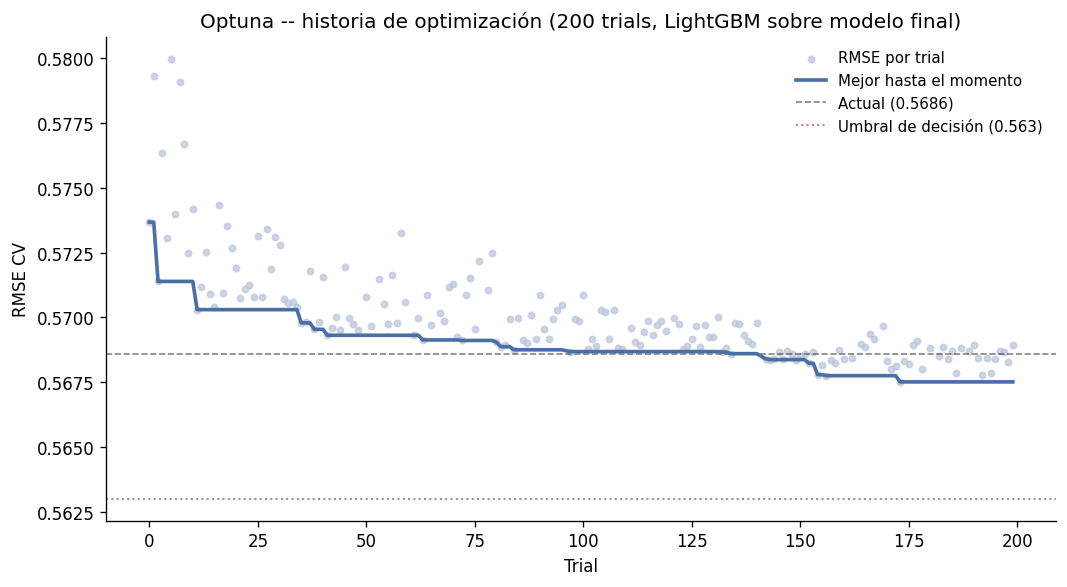

Mejor RMSE CV (Optuna) : 0.5675  (trial #173)
Actual (manual)        : 0.5686 +/- 0.0055
Delta                  : -0.0011
Umbral de decision     : 0.563  ->  NO superado


In [2]:
# Curva de convergencia del estudio de Optuna (200 trials -- ver tuning/optuna_search.py)
# (trial, RMSE CV) de los 185 trials completos, embebido para que esta celda no
# dependa de tuning/optuna_study.db (que no se versiona por su peso).
optuna_trials = [
    (0, 0.57368), (1, 0.57932), (2, 0.57139), (3, 0.57636), (4, 0.57305), (5, 0.57998), (6, 0.57398), (7, 0.57908),
    (8, 0.57668), (9, 0.5725), (10, 0.57418), (11, 0.5703), (12, 0.57119), (13, 0.57254), (14, 0.57091), (15, 0.57042),
    (16, 0.57436), (17, 0.57094), (18, 0.57354), (19, 0.57268), (20, 0.57192), (21, 0.57075), (22, 0.57109), (23, 0.57124),
    (24, 0.57079), (25, 0.57316), (26, 0.57079), (27, 0.57342), (28, 0.57187), (29, 0.57311), (30, 0.57278), (31, 0.57073),
    (32, 0.57056), (33, 0.57059), (34, 0.5704), (35, 0.56979), (36, 0.56984), (37, 0.57179), (38, 0.56954), (39, 0.56984),
    (40, 0.57156), (41, 0.56931), (42, 0.56958), (43, 0.57), (44, 0.5695), (45, 0.57195), (46, 0.56996), (47, 0.56975),
    (48, 0.56952), (50, 0.57077), (51, 0.56967), (53, 0.57147), (54, 0.5705), (55, 0.56973), (56, 0.57162), (57, 0.5698),
    (58, 0.57326), (59, 0.57059), (61, 0.56934), (62, 0.56998), (63, 0.56913), (64, 0.57087), (65, 0.56971), (67, 0.57017),
    (68, 0.56987), (69, 0.57116), (70, 0.57128), (71, 0.56926), (72, 0.56911), (73, 0.57086), (74, 0.57154), (75, 0.56957),
    (76, 0.57216), (78, 0.57104), (79, 0.57249), (80, 0.56904), (81, 0.56887), (82, 0.56894), (83, 0.56992), (84, 0.56875),
    (85, 0.56999), (86, 0.56912), (87, 0.56902), (88, 0.57011), (89, 0.56917), (90, 0.57087), (91, 0.56957), (92, 0.56916),
    (93, 0.56994), (94, 0.57028), (95, 0.57047), (97, 0.56868), (98, 0.56993), (99, 0.56986), (100, 0.57088), (101, 0.56877),
    (102, 0.56917), (103, 0.56891), (104, 0.57027), (105, 0.57019), (106, 0.56918), (107, 0.5703), (108, 0.5688), (109, 0.56879),
    (111, 0.56961), (112, 0.56906), (113, 0.56892), (114, 0.56945), (115, 0.56986), (116, 0.56934), (117, 0.5697), (118, 0.56988),
    (119, 0.56947), (121, 0.56999), (122, 0.56974), (123, 0.56879), (124, 0.5689), (125, 0.56917), (126, 0.56966), (127, 0.56885),
    (128, 0.5697), (129, 0.56926), (130, 0.56923), (131, 0.57001), (132, 0.56866), (133, 0.56881), (134, 0.5686), (135, 0.56979),
    (136, 0.56976), (137, 0.56933), (138, 0.56907), (139, 0.56896), (140, 0.5698), (142, 0.5684), (143, 0.56837), (144, 0.56841),
    (145, 0.56866), (146, 0.56841), (147, 0.5687), (148, 0.56858), (149, 0.56837), (150, 0.56851), (151, 0.5686), (152, 0.56823),
    (153, 0.56867), (154, 0.56779), (155, 0.56815), (156, 0.56775), (157, 0.56836), (158, 0.56825), (159, 0.56876), (160, 0.5684),
    (162, 0.56842), (164, 0.56898), (165, 0.56885), (166, 0.56936), (167, 0.56916), (169, 0.56965), (170, 0.56832), (171, 0.56799),
    (172, 0.56814), (173, 0.56751), (174, 0.56832), (175, 0.5682), (176, 0.56894), (177, 0.5691), (178, 0.56801), (180, 0.56882),
    (182, 0.5685), (183, 0.56887), (184, 0.5684), (185, 0.56869), (186, 0.56786), (187, 0.5688), (189, 0.56869), (190, 0.56893),
    (191, 0.56843), (192, 0.56777), (193, 0.56844), (194, 0.56787), (195, 0.56839), (196, 0.56871), (197, 0.56865), (198, 0.56827),
    (199, 0.56892),
]

trial_nums = np.array([t for t, _ in optuna_trials])
values     = np.array([v for _, v in optuna_trials])
best_so_far = np.minimum.accumulate(values)

CURRENT_RMSE = 0.5686
THRESHOLD    = 0.563

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(trial_nums, values, s=14, color='#B8C4D9', alpha=0.7, label='RMSE por trial', zorder=2)
ax.plot(trial_nums, best_so_far, color='#4A6FA5', linewidth=2.2, label='Mejor hasta el momento', zorder=3)
ax.axhline(CURRENT_RMSE, color='#333333', linestyle='--', linewidth=1, alpha=0.6, label=f'Actual ({CURRENT_RMSE})')
ax.axhline(THRESHOLD, color='#B0605A', linestyle=':', linewidth=1.2, alpha=0.8, label=f'Umbral de decisión ({THRESHOLD})')
ax.set_xlabel('Trial')
ax.set_ylabel('RMSE CV')
ax.set_title('Optuna -- historia de optimización (200 trials, LightGBM sobre modelo final)')
ax.legend(frameon=False, fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

best_idx = values.argmin()
print(f'Mejor RMSE CV (Optuna) : {values[best_idx]:.4f}  (trial #{trial_nums[best_idx]})')
print(f'Actual (manual)        : {CURRENT_RMSE:.4f} +/- 0.0055')
print(f'Delta                  : {values[best_idx] - CURRENT_RMSE:+.4f}')
print(f'Umbral de decision     : {THRESHOLD}  ->  {"SUPERADO" if values[best_idx] < THRESHOLD else "NO superado"}')

### 6.4 Conclusión

**Regla de decisión** (fijada antes de correr el tuning): adoptar los hiperparámetros
de Optuna solo si el RMSE CV bajaba de **0.563**. El mejor de 200 trials dio
**0.5675** — no cruza el umbral.

Más allá del umbral: la mejora de −0.0011 está **dentro del ruido del propio CV**
(std ≈ 0.0054–0.0055 en ambos casos, un orden de magnitud mayor que la diferencia
entre configuraciones). La curva de convergencia lo confirma: el mejor valor se
estabiliza alrededor del trial ~150 y no vuelve a moverse en los 50 trials
siguientes — 200 trials alcanzaron para explorar el espacio, no es que el tuning
se cortó temprano.

> **El techo de este modelo está en la información disponible (weight, year,
> mecánicas, duración…), no en los hiperparámetros de LightGBM.** Para bajar el
> RMSE de forma significativa hace falta más señal — no un LightGBM mejor
> ajustado (ver "Limitaciones y mejoras" en la presentación: embeddings de texto,
> ensemble, etc.).

**Decisión: el modelo actual (hiperparámetros manuales) queda como final.**
No se modificó `03_train_final.ipynb`, `04_predict_test.ipynb` ni se tocó el
holdout en ningún momento del proceso.

Script, estudio de Optuna (resumible), reporte y gráfico de importancia de
hiperparámetros: [`tuning/`](../tuning/).